## [공통코드] 데이터 로딩

In [ ]:
# 구글 드라이브 마운트
from google.colab import drive

drive.mount('/content/drive')

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NUM_OF_CLASS = 3
ROOT_PATH = '/content/drive/MyDrive/_for_exercise/'

In [92]:
# (26, 26) 웨이퍼맵의 failureType을 거의 다 포함하는 pkl (Donut, Near-full 제외)
df = pd.read_pickle(ROOT_PATH + 'WM811K_subset_26x26_full.pkl')


## [공통코드] 데이터 탐색


In [58]:
# waferMap : 웨이퍼맵 데이터
# label : 웨이퍼의 불량 패턴 종류
df.head()

,waferMap,label
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 1, 1, 2,...",none
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 1, 1, 1,...",none
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1, 1,...",none
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 1, 1,...",none
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2,...",none


In [93]:
# 클래스별 데이터 개수 확인
df['label'].value_counts()

,count
label,
none,13489
Loc,297
Edge-Loc,296
Center,90
Random,74
Scratch,72
Edge-Ring,31


In [60]:
# 데이터 구조 확인
print(df.columns)
print(df.shape)

Index(['waferMap', 'label'], dtype='object')
(14349, 2)


In [61]:
# 웨이퍼맵 하나 확인
sample = df['waferMap'].iloc[10] # 0~239

print(type(sample))
print(sample.shape)
print(sample)

# 웨이퍼맵 하나는 NumPy 2차원 배열
# 모든 데이터 크기는 26 × 26

<class 'numpy.ndarray'>
(26, 26)
[[0 0 0 0 0 0 0 0 0 0 2 2 1 1 1 2 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 2 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 2 1 1 2 1 1 1 1 1 1 2 1 1 0 0 0 0 0 0]
 [0 0 0 0 2 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 2 0 0 0 0]
 [0 0 0 1 2 1 1 1 1 1 1 1 1 1 2 1 1 1 1 2 1 1 1 0 0 0]
 [0 0 2 1 1 1 2 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 2 0 0]
 [0 0 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 2 2 1 1 2 1 0 0]
 [0 1 1 2 1 2 1 2 1 1 1 1 1 1 1 1 2 1 1 1 2 1 1 1 1 0]
 [0 1 1 1 1 1 2 2 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 2 2 0]
 [2 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2]
 [1 1 1 1 1 2 1 1 1 1 1 1 2 1 1 1 2 1 1 1 2 1 1 1 1 1]
 [1 1 1 1 2 2 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 2 2 1]
 [1 1 1 2 1 2 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 2 1]
 [2 1 1 1 1 1 1 1 1 1 2 1 2 1 2 1 1 2 1 1 1 2 2 1 1 1]
 [1 1 1 1 1 1 1 1 1 2 2 1 2 1 1 1 2 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 1 2 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 1 1 1]
 [0 2 1 1 1 1 1 1 1 1 1 1 1 1 1 

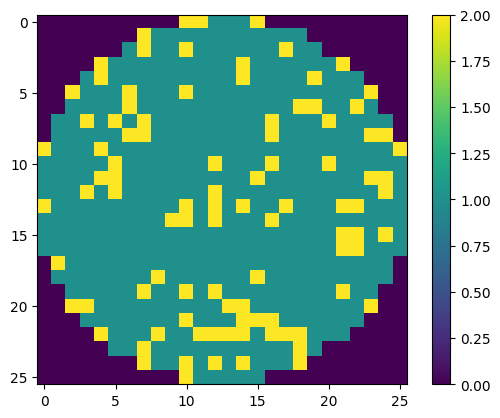

In [62]:
# 웨이퍼맵 시각화
plt.imshow(sample)
plt.colorbar()
plt.show()

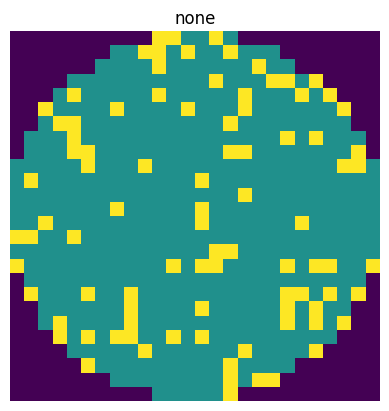

In [63]:
# 라벨과 함께 출력
sample = df.iloc[0]

plt.imshow(sample['waferMap'])
plt.title(sample['label'])
plt.axis('off')
plt.show()

In [64]:
# 현재 클래스 종류를 리스트로 만들기
NUM_OF_CLASS = df['label'].nunique()
class_list = []

for i in range(NUM_OF_CLASS) :
    class_list.append(str(np.unique(df['label'])[i]))

print(NUM_OF_CLASS)
print(class_list)

7
['Center', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Random', 'Scratch', 'none']


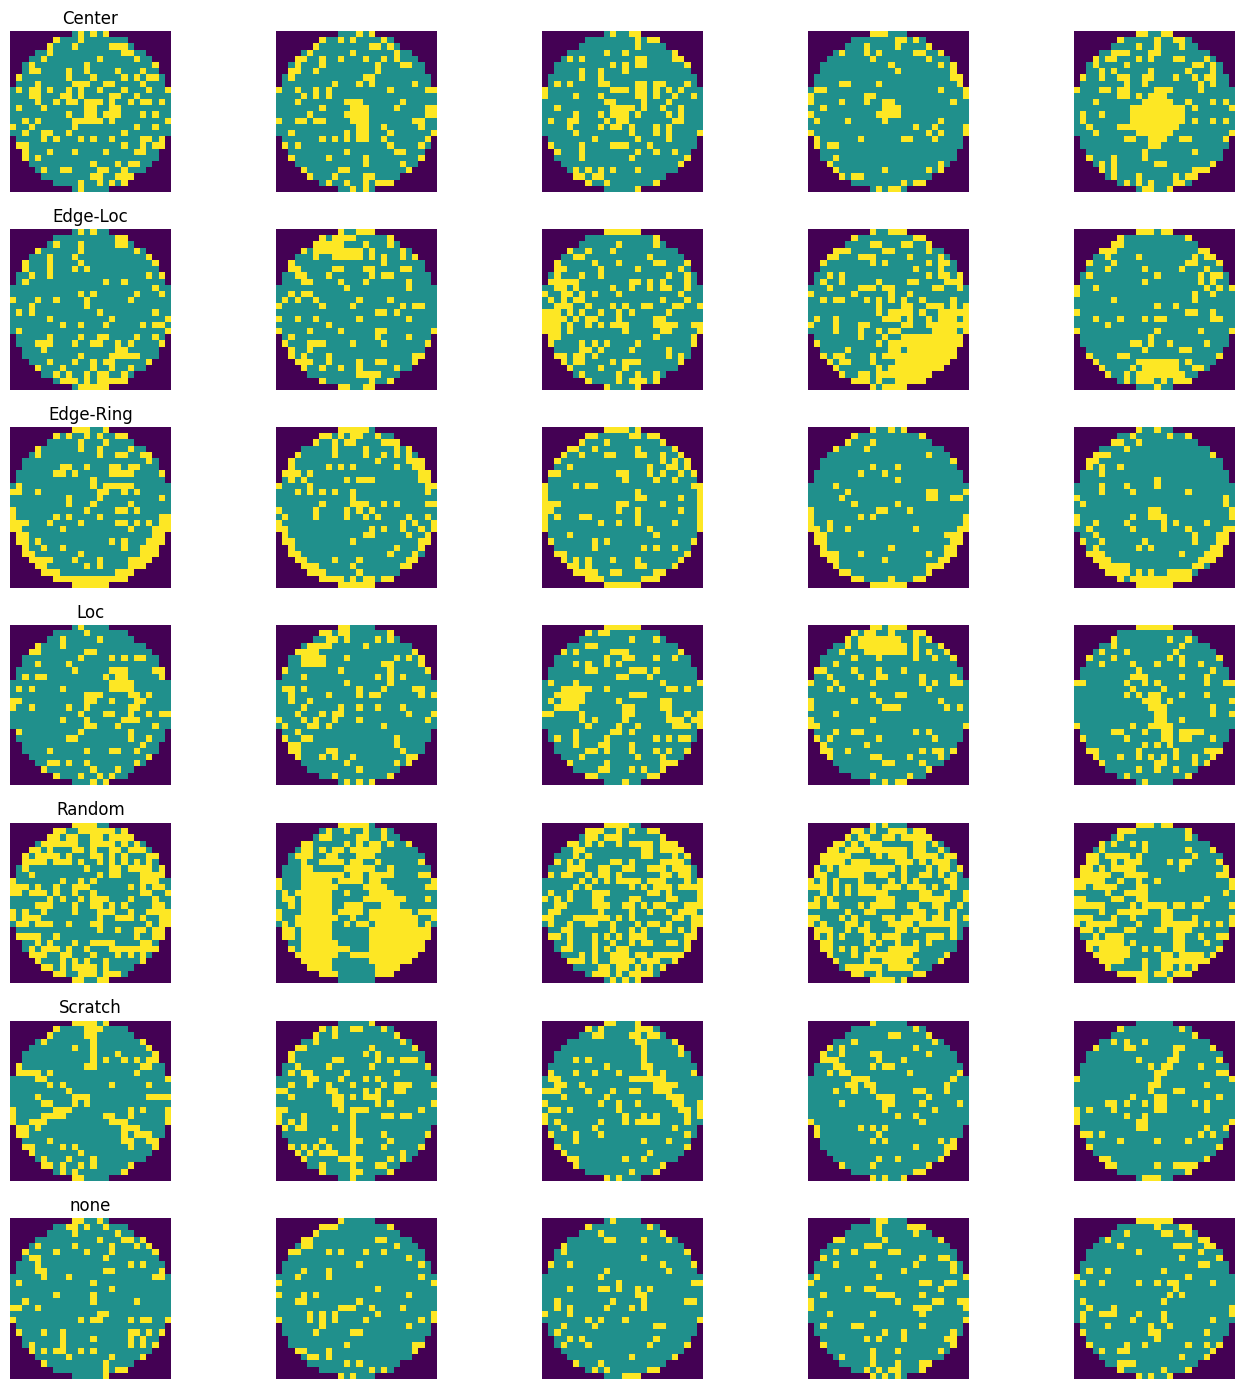

In [65]:
# 클래스별 웨이퍼맵 비교
# 같은 클래스라도 모양이 완전히 동일하지 않음
fig, axes = plt.subplots(NUM_OF_CLASS, 5, figsize=(NUM_OF_CLASS*2, NUM_OF_CLASS*2))

for row, cls in enumerate(class_list):

    samples = df[df['label'] == cls].head(5)

    for col, (_, sample) in enumerate(samples.iterrows()):

        axes[row, col].imshow(sample['waferMap'])
        axes[row, col].axis('off')

        if col == 0:
            axes[row, col].set_title(cls)

plt.tight_layout()
plt.show()


---
# 실습 1. Edge-Loc, Center, Scratch
* 60개로 자르지 말고 있는 데이터 모두 사용해서 모델 학습시켜보기

In [71]:
target_class = ['Edge-Loc', 'Center', 'Scratch']
NUM_OF_CLASS = len(target_class)

selected_df = df[df['label'].isin(target_class)]

In [72]:
selected_df['label'].value_counts()

,count
label,
Edge-Loc,296
Center,90
Scratch,72


---
# 2. 실습 2. Edge-Loc, Center, Scratch, Random

* Random을 추가해서 4개 클래스 분류 모델 학습시켜보기



In [94]:
target_class = ['Edge-Loc', 'Center', 'Scratch', 'Random']
NUM_OF_CLASS = len(target_class)

selected_df = df[df['label'].isin(target_class)]

In [95]:
selected_df['label'].value_counts()

,count
label,
Edge-Loc,296
Center,90
Random,74
Scratch,72


---
# 3. 실습 3. Edge-Loc, Center, Scratch, none

* -> none의 샘플 수를 늘려가면서 비교해보기
* -> none이 180일 때, 300일 때
* -> none이 늘어나면 모델이 none의 특징을 더 잘 학습할까?

In [117]:
target_class = ['Edge-Loc', 'Center', 'Scratch']
NUM_OF_CLASS = len(target_class)
NUM_OF_NONE_SAMPLE = 180

selected_df = df[df['label'].isin(target_class)]

none_class = df[df['label'] == 'none'].sample(n=NUM_OF_NONE_SAMPLE, random_state=42).reset_index(drop=True)
selected_df = pd.concat([selected_df, none_class], ignore_index=True)

In [118]:
selected_df['label'].value_counts()

,count
label,
Edge-Loc,296
none,180
Center,90
Scratch,72


---
# [공통코드] 4. CNN 학습용 데이터 만들기

## 4.1 입력 데이터 `X` 만들기




In [96]:
# waferMap 컬럼의 2차원 배열을 하나의 NumPy 배열로 묶음.
X = np.stack(selected_df['waferMap'].values)

print(X.shape)

(532, 26, 26)


In [97]:
# 현재 shape: (180, 26, 26)
# CNN 입력을 위해 채널 차원 추가 필요

X = X[..., np.newaxis]

print(X.shape)

# - 변경 후 shape: `(180, 26, 26, 1)`
# - 마지막 `1`은 채널 수

(532, 26, 26, 1)


## 4.2 정답 데이터 `y` 만들기

In [98]:
from sklearn.preprocessing import LabelEncoder

# 문자열 라벨을 숫자로 변환함.
le = LabelEncoder()

y = le.fit_transform(selected_df['label'])

print(le.classes_)
print(y[:10])
# 문자열 클래스 → 숫자 라벨로 변환
# 클래스 번호는 le.classes_ 순서에 따라 결정됨

[np.str_('Center') np.str_('Edge-Loc') np.str_('Random')
 np.str_('Scratch')]
[1 1 1 1 1 1 1 3 2 0]


## 4.3 클래스별 데이터 수 확인

In [99]:
print(np.bincount(y))
# 각 클래스 60개씩 구성됨

[ 90 296  74  72]


## 4.4 학습용 / 검증용 데이터 분리

In [100]:
from sklearn.model_selection import train_test_split

# 학습 데이터: 80%
# 검증 데이터: 20%
# stratify=y로 클래스 비율 유지
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 4.5 픽셀값 정규화

In [101]:
# 웨이퍼맵 값은 0, 1, 2로 구성됨.

X_train = X_train / 2.0
X_val = X_val / 2.0

# 정규화 후 값 확인:
print(X_train.min())
print(X_train.max())
# 기존 범위: 0 ~ 2
# 정규화 후 범위: 0 ~ 1

0.0
1.0


## 4.6 최종 입력 형태 확인

In [102]:
print('X_train:', X_train.shape)
print('X_val:', X_val.shape)
print('y_train:', y_train.shape)
print('y_val:', y_val.shape)

X_train: (425, 26, 26, 1)
X_val: (107, 26, 26, 1)
y_train: (425,)
y_val: (107,)


---

# [공통코드] 5. CNN 모델 구현 및 학습

## 5.1 CNN 모델 만들기

In [103]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Input(shape=(26, 26, 1)),

    Conv2D(16, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(32, activation='relu'),
    # 분류 출력층의 노드는 클래스 개수와 동일해야 함
    Dense(NUM_OF_CLASS, activation='softmax')
])

# - 입력 크기: `26 × 26 × 1`
# - 출력 클래스: 3개
# - Conv2D + MaxPooling2D를 2번 사용함

## 5.2 모델 구조 확인

In [104]:
model.summary()
# - 각 층의 출력 shape 확인
# - 학습할 파라미터 수 확인

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,564 (119.39 KB)

 Trainable params: 30,564 (119.39 KB)

 Non-trainable params: 0 (0.00 B)

## 5.3 모델 컴파일

In [105]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# - optimizer: `adam`
# - 다중 클래스 분류 문제
# - 정답이 숫자 라벨이므로 `sparse_categorical_crossentropy` 사용

## 5.4 모델 학습

In [106]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1
)

# - `epochs=20`: 전체 학습 데이터를 20번 반복
# - `batch_size=16`: 한 번에 16개씩 학습
# - 학습 데이터와 검증 데이터 성능 함께 확인

Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5553 - loss: 1.2269 - val_accuracy: 0.5607 - val_loss: 1.1687
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5553 - loss: 1.1766 - val_accuracy: 0.5607 - val_loss: 1.1503
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.5553 - loss: 1.1436 - val_accuracy: 0.5607 - val_loss: 1.1216
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5553 - loss: 1.1079 - val_accuracy: 0.5607 - val_loss: 1.1063
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5553 - loss: 1.0627 - val_accuracy: 0.5607 - val_loss: 1.0324
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5600 - loss: 0.9783 - val_accuracy: 0.5701 - val_loss: 0.9203
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6165 - loss: 0.8615 - val_accuracy: 0.6636 - val_loss: 0.8024
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7012 - loss: 0.7640 - val_accuracy: 0.6822 - v

## 5.5 학습 결과 확인

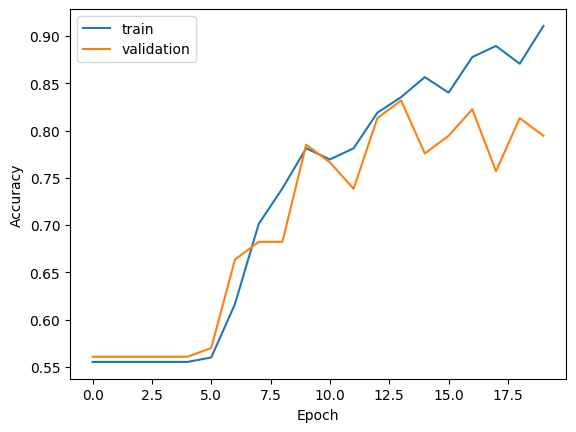

In [107]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# - 학습이 진행되면서 정확도가 어떻게 변하는지 확인
# - train과 validation의 차이 관찰

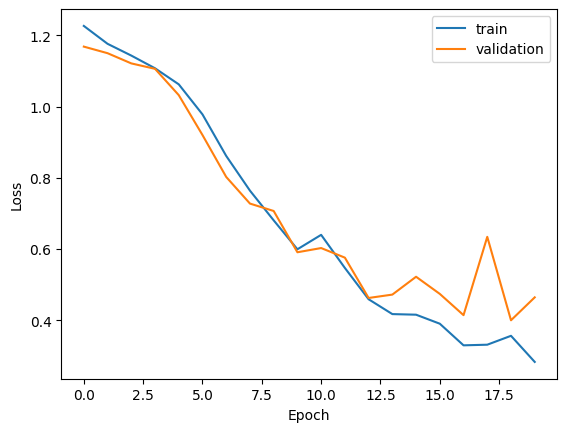

In [108]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# - loss가 감소하는지 확인
# - validation loss가 다시 증가하면 과적합 가능성 있음


---
# [공통코드] 6. 모델 성능 확인

## 6.1 예측 결과 만들기

In [109]:
y_pred = model.predict(X_val)

y_pred = np.argmax(y_pred, axis=1)

print(y_pred[:10])

# - softmax 출력에서 가장 큰 값을 가진 클래스 선택
# - 예측 결과를 클래스 번호로 변환함

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
[2 2 1 1 1 1 2 1 0 2]


## 6.2 실제값과 예측값 비교

In [110]:
print('실제값:', y_val[:10])
print('예측값:', y_pred[:10])

# - 예측이 맞은 경우와 틀린 경우 확인

실제값: [1 2 1 1 1 3 2 1 0 2]
예측값: [2 2 1 1 1 1 2 1 0 2]


## 6.3 Confusion Matrix 확인

[np.str_('Center') np.str_('Edge-Loc') np.str_('Random')
 np.str_('Scratch')]


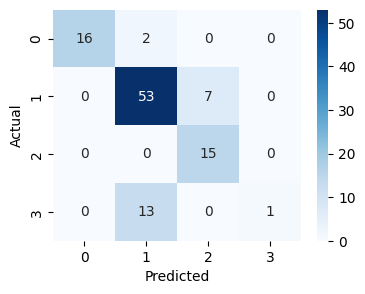

In [111]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# - confusion matrix의 클래스 순서 확인
# - 숫자 라벨과 실제 클래스 이름 연결
print(le.classes_)
print("="*50)

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(4,3))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# - 행: 실제 클래스
# - 열: 예측 클래스
# - 어떤 클래스끼리 많이 헷갈리는지 확인 가능

## 6.4 Classification Report 확인

In [112]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        y_pred,
        target_names=le.classes_
    )
)

# - precision
# - recall
# - f1-score
# - 클래스별 성능 비교 가능

              precision    recall  f1-score   support

      Center       1.00      0.89      0.94        18
    Edge-Loc       0.78      0.88      0.83        60
      Random       0.68      1.00      0.81        15
     Scratch       1.00      0.07      0.13        14

    accuracy                           0.79       107
   macro avg       0.87      0.71      0.68       107
weighted avg       0.83      0.79      0.75       107



## 6.5 오분류 데이터 확인

In [113]:
# 예측이 틀린 데이터의 인덱스 확인

wrong_idx = np.where(y_val != y_pred)[0]

print('오분류 개수:', len(wrong_idx))
print(wrong_idx[:10])

오분류 개수: 22
[ 0  5 12 13 17 22 28 35 36 39]


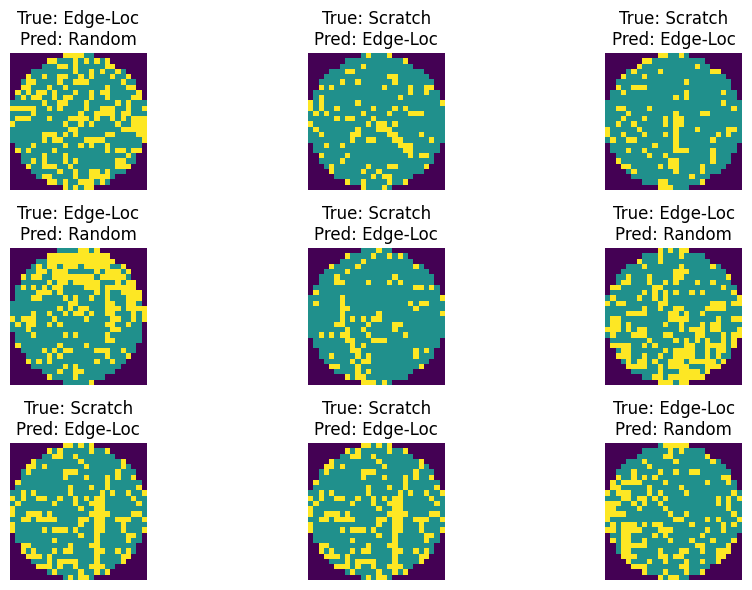

In [114]:
# 오분류 이미지 시각화
plt.figure(figsize=(10, 6))

for i, idx in enumerate(wrong_idx[:9]):

    plt.subplot(3, 3, i + 1)

    plt.imshow(X_val[idx].squeeze())

    true_label = le.inverse_transform([y_val[idx]])[0]
    pred_label = le.inverse_transform([y_pred[idx]])[0]

    plt.title(
        f'True: {true_label}\nPred: {pred_label}'
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

# - 실제 라벨과 예측 라벨 비교
# - 모델이 어떤 형태의 웨이퍼맵에서 헷갈리는지 직접 확인

